# PFDA Project: E-Commerce & Consumer Behaviour

## **1. Introduction & Setup**

Understanding consumer behaviour is central to effective decision-making in modern e-commerce environments. By analysing customer demographics, purchasing behaviour, and engagement signals, organisations can design more targeted marketing strategies, optimise product offerings, and improve customer retention.

This project leverages a comprehensive Customer Shopping Trends Dataset to explore key drivers of purchasing behaviour, profile diverse customer segments, and derive actionable strategic insights. Through this analysis, the aim is to translate data into a deeper understanding of consumer preferences and patterns to support competitive advantage in the digital marketplace.

**Importing the necessary libraries**

In [59]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os

# Database interaction
import sqlite3

# Visualisation libraries
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Scikit-learn for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Geolocation and date handling
import geonamescache as gc

# Machine learning library
from datetime import datetime


# Confirmation message
print("Libraries loaded successfully!")

Libraries loaded successfully!


The next section introduces the dataset and outlines how the raw data was acquired and initially inspected.

## **2. Data Acquisition**

Before any meaningful analysis can be performed, it is essential to understand the structure, scope, and origin of the data. The quality and characteristics of the dataset directly influence the reliability of downstream analysis and modelling

### 2.1 Loading the Dataset

In [60]:
# Loading the CSV file
FILENAME = "Ecommerce_Consumer_Behavior_Analysis_Data.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a DataFrame with error handling
if os.path.exists(FULLPATH):
	df = pd.read_csv(FULLPATH, encoding='utf-8')
	print(f"Dataset shape: {df.shape}")
else:
	print(f"File not found: {FULLPATH}")
	print("Please check the file path and ensure the data directory exists")

# Display the first few rows of the DataFrame
display(df.head(10))

# Source of dataset: https://www.kaggle.com/datasets/syedamiralam/ecommerce-consumer-behavior-analysis-data
# Source: https://www.datacamp.com/tutorial/pandas-read-csv

Dataset shape: (1000, 28)


,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4
5,82-561-4233,45,Male,Middle,Married,Master's,High,Boro Utara,Office Supplies,$487.95,...,3,NaN,Tablet,Debit Card,3/19/2024,False,False,Planned,No Preference,7
6,90-144-9193,21,Female,Middle,Divorced,High School,Middle,Liren,Furniture,$486.40,...,9,Low,Desktop,Debit Card,3/15/2024,True,False,Need-based,Express,13
7,88-661-4689,39,Male,Middle,Single,High School,Middle,Taocheng,Books,$218.06,...,9,NaN,Desktop,Credit Card,3/17/2024,False,True,Impulsive,No Preference,13
8,37-065-3182,24,Female,High,Divorced,Master's,Middle,Gråbo,Office Supplies,$201.96,...,2,High,Desktop,Cash,6/10/2024,False,False,Need-based,Standard,7
9,84-894-9222,25,Bigender,High,Married,Bachelor's,High,Pryamitsyno,Sports & Outdoors,$418.83,...,5,Medium,Tablet,PayPal,10/7/2024,True,False,Need-based,No Preference,13


### 2.2 Initial Data Inspection

In [61]:
# DataFrame information
df.info()

# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

This section described the process of loading and inspecting the customer shopping trends dataset. Initial exploration confirmed the presence of both numerical and categorical variables capturing customer demographics, purchasing behaviour, and engagement metrics, as well as missing values in selected fields. These observations motivate the data cleaning and pre-processing steps undertaken in the following section.

## **3. Data Cleaning**

Real-world datasets frequently contain inconsistencies, missing values, and features that require transformation before analysis. Addressing these issues is critical to ensuring valid statistical results and robust modelling outcomes.

### 3.1 Converting Data Type

In [62]:
# Check if Purchase_Amount is object type (string), if so convert it
if df['Purchase_Amount'].dtype == 'object':
	df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '', regex=False).astype(float).round(2)

# Source: https://pandas.pydata.org/docs/user_guide/text.html (Splitting and replacing strings)

### 3.2 Handling Missing Value

In [63]:
# Missing values can impact on both exploratory analysis and predictive modelling.

# Select columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns # Numerical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns  # Categorical columns

# Missing values before imputation
print("Missing values before imputation :")
print(df.isnull().sum())

# Impute numerical columns using median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical columns using mode
for col in cat_cols: 
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val[0])
    else:
        df[col] = df[col].fillna('Unknown')  # Or drop the column if fully missing

# Missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Source: https://www.w3schools.com/python/pandas/pandas_missing_data.asp (Handling Missing Data in pandas)
# Source: https://www.geeksforgeeks.org/python-pandas-dataframe-fillna-method/ (fillna() method)
# Source: https://scikit-learn.org/stable/modules/impute.html (Imputation of missing values)
# Source: https://pandas.pydata.org/docs/ (pandas official documentation)

Missing values before imputation :
Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method      

### 3.3 Outlier Detection

Remove outliers using [IQR](https://www.geeksforgeeks.org/machine-learning/interquartile-range-to-detect-outliers-in-data/), for accuracy:



In [64]:
# Outliers can skew statistical analysis and negatively impact machine learning models

# Update numerical columns selection to include Purchase_Amount after type conversion
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using the IQR method
outlier_summary = {}

# The Interquartile Range (IQR) method is used to identify potential outliers in numerical variables
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_summary[col] = outliers.shape[0]

# Display outlier counts
pd.Series(outlier_summary, name="Outlier_Count")

# Source: https://medium.com/@kdbaba124/outlier-detection-the-odd-ones-that-matter-in-business-analytics-b3b8911f558d
# Source: https://substack.com/home/post/p-177530415 (How Your Best Customers Should Shape Your Product Roadmap)
# Source: https://www.geeksforgeeks.org/data-science/detect-and-remove-the-outliers-using-python/


Age                                      0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Return_Rate                              0
Customer_Satisfaction                    0
Time_to_Decision                         0
Name: Outlier_Count, dtype: int64

### 3.4 Date & Time Processing

In [65]:
# Convert 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
print("Converted 'Time_of_Purchase' to datetime format.")

# Source: https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html (pandas to_datetime() documentation)

Converted 'Time_of_Purchase' to datetime format.


The "Location" column seem to have too many different cities, which can be difficult to profile our customers. We'll group them bu countries, as it is  easier to manipulate the data, using geopy.geocoders (Nominatim)

Source: [GeeksforGeeks](https://www.geeksforgeeks.org/python/get-the-city-state-and-country-names-from-latitude-and-longitude-using-python/)

### 3.5 Age groups

And we'll create group ages, to simplify demographic analysis and improve the interpretation of customer segments.

In [66]:
# First create Age_Group from Age column
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Now, we'll check the age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts.columns = ['Age_Group', 'Count']

age_group_counts

# Source: https://pandas.pydata.org/docs/reference/api/pandas.cut.html (pandas cut() documentation)
# Source: https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/ (pandas cut() function)
# Source: https://realpython.com/pandas-groupby/ (pandas GroupBy)

Age_Group
18-25    222
26-35    308
36-45    320
46-55    150
55+        0
Name: count, dtype: int64

In [67]:
# Remove unused age group if present
if '55+' in age_group_counts.index and age_group_counts.loc['55+'] == 0:
    df['Age_Group'] = df['Age_Group'].cat.remove_categories(['55+'])
    age_group_counts = df['Age_Group'].value_counts().sort_index()

print("Age Group Distribution:")
print(age_group_counts)

# Source: https://pandas.pydata.org/docs/reference/api/pandas.CategoricalIndex.remove_categories.html (remove_categories() documentation)
# Source: https://stackoverflow.com/questions/50895976/grouping-age-into-custom-sections (Grouping Age into custom Sections)

Age Group Distribution:
Age_Group
18-25    222
26-35    308
36-45    320
46-55    150
Name: count, dtype: int64


### 3.6 Standardising Country Names

Offline geolocation mapping was implemented using the geonamescache package, which provides city and country reference data derived from the GeoNames database. This approach supports reproducible analysis without reliance on external APIs, while requiring validation of mapping coverage prior to geographic analysis.

In [68]:
# Offline geolocation mapping using geonamescache
geocache = gc.GeonamesCache()

cities = geocache.get_cities()  # Dictionary of city IDs to details
countries = geocache.get_countries()  # Dictionary of country codes to details

# Build mapping: lowercase city name -> country name (English)
city_to_country = {city['name'].lower(): countries[city['countrycode']]['name']
    for city in cities.values()
   if city['countrycode'] in countries} # English names only

# Add common aliases/variants if needed (e.g., 'nyc' -> 'new york')
# city_to_country['nyc'] = 'United States'

# Create Country column
df['Country'] = df['Location'].str.lower().map(city_to_country)

print(f"Country mapping coverage: {df['Country'].notna().sum()} / {len(df)} rows")

# Source: https://stackoverflow.com/questions/60396125/pandas-apply-cell-value-to-geonamescache-function-large-file (geonamescache function)
# Source: https://pypi.org/project/geonamescache/0.13/ (geonamescache documentation)

# Initially, the author used geopy library for geolocation, but switched to geonamescache for offline mapping due to API rate limits
# and performance considerations (it was taking longer than 20 minutes to load the required information).87777                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 


Country mapping coverage: 386 / 1000 rows


### 3.7 Grouping Genders

In [69]:
# When calculating the average purchase amount per gender, for example, there are many genders listed.
# This could skew the results as it might not be representative enough throughout the dataset.

# Genders and Average Purchase Amount
result = df.groupby('Gender')['Purchase_Amount'].mean()

print("Average Purchase Amount by Gender:")
print(result)

Average Purchase Amount by Gender:
Gender
Agender        243.777368
Bigender       258.469500
Female         282.087854
Genderfluid    295.223529
Genderqueer    279.517500
Male           267.618463
Non-binary     287.730625
Polygender     308.108000
Name: Purchase_Amount, dtype: float64


In [70]:
# Group any other gender that is not Female or Male into Other
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Female', 'Male'] else 'Other') # Standardising gender
print("Unique genders after grouping:", df['Gender'].unique())

# Calculate average purchase per gender
result = df.groupby('Gender')['Purchase_Amount'].mean().round(2)
print("New purchase averages after grouping:", result)

# Source: https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html (Documentation)
# Source: https://www.w3schools.com/python/pandas/ref_df_groupby.asp (pandas groupby())
# Source: https://www.datacamp.com/tutorial/python-lambda-functions (Python Lambda Functions)

Unique genders after grouping: ['Female' 'Male' 'Other']
New purchase averages after grouping: Gender
Female    282.09
Male      267.62
Other     276.76
Name: Purchase_Amount, dtype: float64


### 3.8 Categorical Variables & Column Standardisation

In [71]:
# Review categorical variable distributions
df['Payment_Method'].value_counts()
df['Purchase_Channel'].value_counts()
df['Device_Used_for_Shopping'].value_counts()

# Rename columns for improved readability and consistency
df.rename(columns={'Device_Used_for_Shopping': 'Device_Used','Customer_Loyalty_Program_Member': 'Loyalty_Program_Member'}, inplace=True)

# Confirm column updates
df.columns

# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html (pandas.DataFrame.rename documentation)

Index(['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status',
       'Education_Level', 'Occupation', 'Location', 'Purchase_Category',
       'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel',
       'Brand_Loyalty', 'Product_Rating',
       'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence',
       'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction',
       'Engagement_with_Ads', 'Device_Used', 'Payment_Method',
       'Time_of_Purchase', 'Discount_Used', 'Loyalty_Program_Member',
       'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision',
       'Age_Group', 'Country'],
      dtype='object')

In [72]:
# Ensure categorical values are stripped and consistently formatted
for col in ['Payment_Method', 'Purchase_Channel', 'Device_Used']:
    df[col] = df[col].str.strip().str.title()

    print(f"Unique values in {col} after cleaning:", df[col].unique())

# Source: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html (pandas str.strip() documentation)
# Source: https://www.geeksforgeeks.org/python/get-unique-values-from-a-column-in-pandas-dataframe/ (Unique Values from a Column)

Unique values in Payment_Method after cleaning: ['Credit Card' 'Paypal' 'Debit Card' 'Other' 'Cash']
Unique values in Purchase_Channel after cleaning: ['Mixed' 'In-Store' 'Online']
Unique values in Device_Used after cleaning: ['Tablet' 'Smartphone' 'Desktop']


### 3.9 Saving the Cleaned Dataset

The cleaned dataset is saved to a new CSV file to ensure it can be reproduced and allow us to use it again in later stages of the analysis without repeating data preparation.

In [73]:
# Saving cleaned data to a new CSV file  for easy access later
CLEAN_FILENAME = "consumer_behaviour_clean.csv"
CLEAN_FULLPATH = "data/" + CLEAN_FILENAME
df.to_csv(CLEAN_FULLPATH, index=False)

print(f"Cleaned data saved to: {CLEAN_FULLPATH}")

Cleaned data saved to: data/consumer_behaviour_clean.csv


This section detailed the data preparation process, including type conversions, missing value imputation, feature engineering, and standardisation of categorical variables. Key transformations such as age grouping, gender consolidation, and geographic mapping were applied to improve interpretability and analytical consistency. The cleaned dataset provides a reliable foundation for exploratory data analysis, which is presented in the next section.

## 4. Exploratory Data Analysis (EDA)

With the dataset cleaned and standardised, exploratory data analysis was conducted to uncover patterns, relationships, and trends in customer behaviour. EDA serves both for descriptive and diagnostic purposes, guiding feature selection and informing subsequent modelling decisions.

### 4.1 Overview of Numerical Variables

In [115]:
# Statistical summary of the DataFrame (taking into account only numerical columns)
df.describe().round(2).T

# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html (pandas DataFrame.describe documentation)
# Source: https://www.geeksforgeeks.org/python/pandas-dataframe-t-function-in-python/ (DataFrame.T function)

,count,mean,min,25%,50%,75%,max,std
Age,1000.0,34.3,18.0,26.0,34.5,42.0,50.0,9.35
Purchase_Amount,1000.0,275.06,50.71,162.24,276.16,388.98,498.33,131.53
Frequency_of_Purchase,1000.0,6.94,2.0,4.0,7.0,10.0,12.0,3.15
Brand_Loyalty,1000.0,3.03,1.0,2.0,3.0,4.0,5.0,1.42
Product_Rating,1000.0,3.03,1.0,2.0,3.0,4.0,5.0,1.44
Time_Spent_on_Product_Research(hours),1000.0,1.01,0.0,0.0,1.0,2.0,2.0,0.79
Return_Rate,1000.0,0.95,0.0,0.0,1.0,2.0,2.0,0.81
Customer_Satisfaction,1000.0,5.4,1.0,3.0,5.0,8.0,10.0,2.87
Time_of_Purchase,1000,2024-06-29 06:31:40.800000,2024-01-01 00:00:00,2024-04-04 00:00:00,2024-06-30 00:00:00,2024-09-19 00:00:00,2024-12-30 00:00:00,NaN
Time_to_Decision,1000.0,7.55,1.0,4.0,8.0,11.0,14.0,4.04


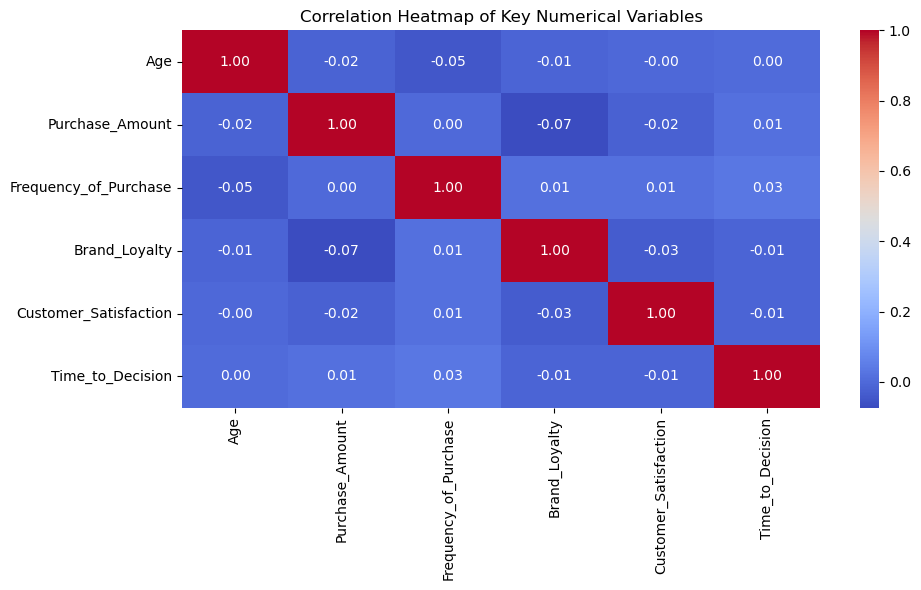

In [116]:
# Correlation heatmap for key numerical variables
plt.figure(figsize=(10,6))
corr = df[['Age', 'Purchase_Amount', 'Frequency_of_Purchase',
     'Brand_Loyalty', 'Customer_Satisfaction', 'Time_to_Decision']].corr()

# Plotting the heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Numerical Variables")
plt.tight_layout()

# Saving the plot
PLOTS_DIR = "plots/"
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOTS_DIR, "correlation_matrix.png"))

plt.show()

# Source: https://python-graph-gallery.com/92-control-color-in-seaborn-heatmaps/ (Colours in seaborn heatmaps)
# Source: https://www.geeksforgeeks.org/python/how-to-create-a-seaborn-correlation-heatmap-in-python/ (Seaborn correlation heatmap)

The heatmap highlights modest correlations between behavioural variables and purchase amount, supporting their inclusion in the predictive modelling stage.

###  4.2 Customer Demographic Profile

#### 4.2.1 Age Distribution

In [117]:
# Average age
average_age = df['Age'].mean()
print(f"The average age of customers is: {average_age:.2f} years")

The average age of customers is: 34.30 years


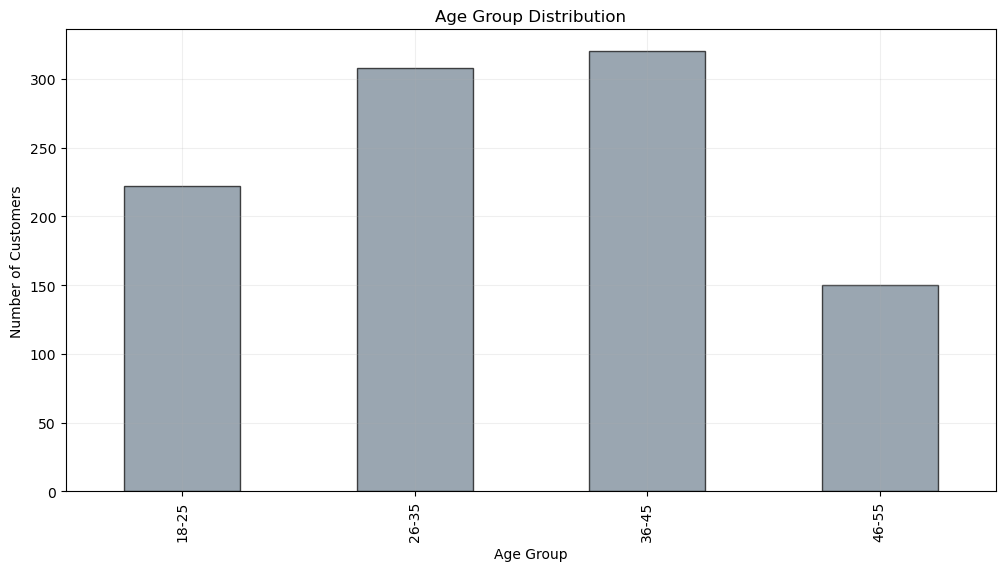

In [118]:
# Age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts.columns = ['Age_Group', 'Count']

# Plotting the age group distribution
plt.figure(figsize=(12, 6))
age_group_counts.plot(kind='bar', edgecolor='black', color='slategrey', alpha=0.7)

# Formatting the plot
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.2)

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "age_group_distribution.png"))

plt.show()

#### 4.2.2 Gender Distribution 

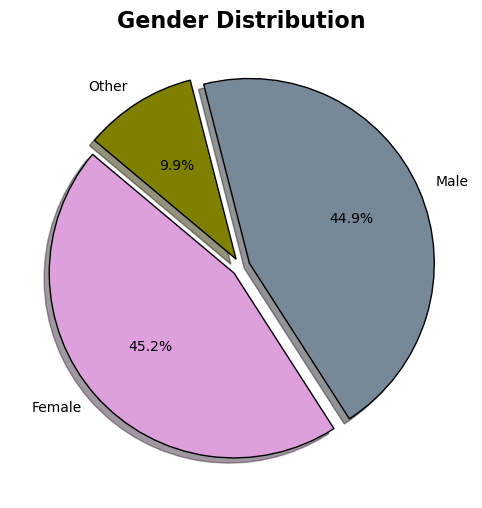

In [119]:
# Calculate gender distribution
gender_counts = df['Gender'].value_counts()

# Splittting the slices for better visibility
explode = [0.05] * len(gender_counts)

# Formatting the plot
plt.figure(figsize=(12, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', explode=explode, colors=['plum', 'lightslategray', 'olive'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=140)
plt.title("Gender Distribution", fontsize=16, fontweight='bold')

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "gender_distribution.png"))

plt.show()

The gender distribution illustrates the composition of the customer base, which is important for tailoring marketing messages and product offerings to different customer segments.

The boxplot shows that purchase amount varies across different levels of purchase intent. Higher intent levels are associated with higher median spending and greater variability, suggesting that intent is a strong indicator of purchase value.

### 4.3 Purchasing Behaviour by Age Segment

In [120]:
# Define desired age group order
desired_order = ['18-25', '26-35', '36-45', '46-55']

# Keeping categories that  already exist
existing_categories = [cat for cat in desired_order if cat in df['Age_Group'].cat.categories]

# Reorder categories safely with ordered=True
df['Age_Group'] = df['Age_Group'].cat.reorder_categories(existing_categories, ordered=True)

# Create the boxplot of average purchase amount by age group
fig = px.box(df, x='Age_Group', y='Purchase_Amount', color='Age_Group', 
             title='Purchase Amount Distribution by Age Group',
             category_orders={'Age_Group': existing_categories})

fig.update_layout(width=1300, height=800)
fig.show()

Purchase amounts are visualised using a boxplot to compare the distribution, median, and variability across age groups. The plot shows that some age groups exhibit higher differences in purchase amounts, while others display more consistent spending behaviour.

### 4.4 Product & Category Performance

#### 4.4.1 Revenue Contribution by Product Category

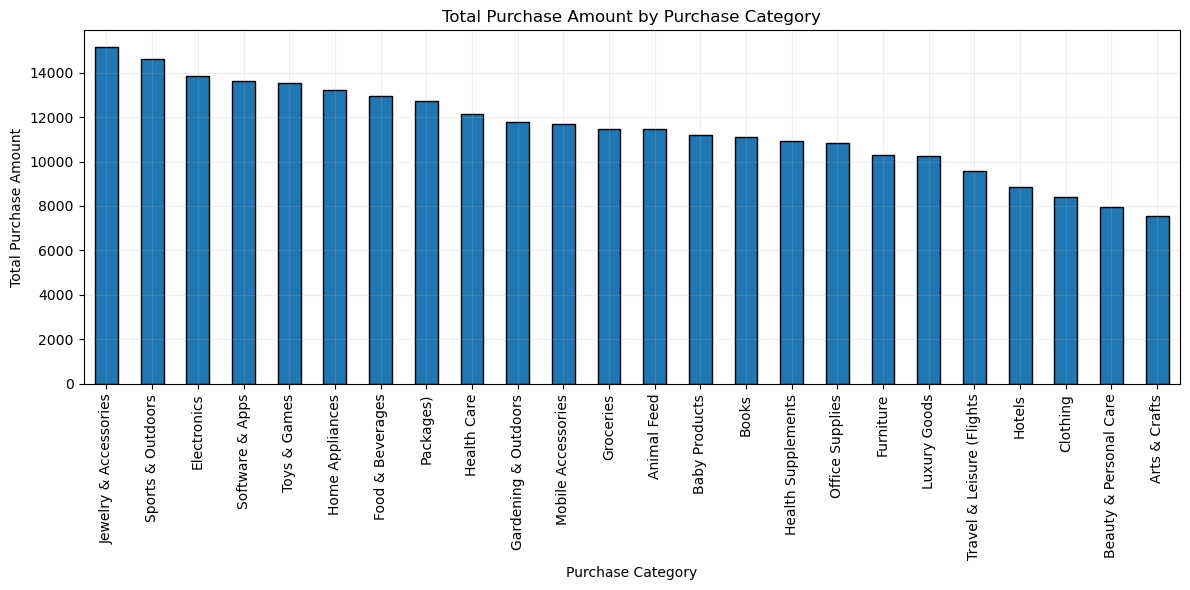

In [121]:
# Total revenue by purchase category
category_revenue = (df.groupby("Purchase_Category")["Purchase_Amount"].sum().sort_values(ascending=False))

# Plotting the category revenue
plt.figure(figsize=(12, 6))
category_revenue.plot(kind="bar", edgecolor="black")

# Formatting the plot
plt.title("Total Purchase Amount by Purchase Category")
plt.ylabel("Total Purchase Amount")
plt.xlabel("Purchase Category")
plt.grid(alpha=0.2)
plt.tight_layout()

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "purchase_category_revenue.png"))

plt.show()

The results show that revenue is concentrated in a small number of product categories -- this insight can inform inventory planning, marketing focus, and product strategy by prioritising high-revenue categories.

#### 4.4.2 Category Preferences by Demographic Segments

In [122]:
# Category Preferences by Demographic Segments
category_age_group = pd.crosstab(df['Purchase_Category'], df['Age_Group'], normalize='columns') * 100

# Select the top 3 categories per age group
top_3_age_group = category_age_group.apply(lambda x: x.nlargest(3).index.tolist(), axis=0)
top_3_age_group

Age_Group,18-25,26-35,36-45,46-55
0,Sports & Outdoors,Groceries,Electronics,Toys & Games
1,Mobile Accessories,Animal Feed,Jewelry & Accessories,Beauty & Personal Care
2,Office Supplies,Food & Beverages,Packages),Food & Beverages


### 4.5 Purchase Intent & Decision Behaviour

#### 4.5.1 Purchase Amount by Purchase Intent

In [123]:
# Purchase intent distribution
purchase_intent_counts = df['Purchase_Intent'].value_counts()

# Creating boxplots for Purchase Amount by Purchase Intent using plotly
fig = px.box(df, x='Purchase_Intent', y='Purchase_Amount', color='Purchase_Intent', title="Purchase Amount Distribution by Purchase Intent",
             color_discrete_sequence=px.colors.qualitative.Bold)

fig.update_layout(width=1300, height=800)
fig.show()

#### 4.5.2 Time to Decision & Behavioural Signals

In [124]:
# Average time to decision age group (in minutes)
avg_time_to_decision = df.groupby('Age_Group', observed=False)['Time_to_Decision'].mean().sort_index()
avg_time_to_decision

Age_Group
18-25    7.279279
26-35    7.561688
36-45    7.728125
46-55    7.526667
Name: Time_to_Decision, dtype: float64

### 4.6 Channels, Devices & Payment Preferences

#### 4.6.1 Purchase Channel Preferences by Age Group

In [125]:
# Which Shopping Channel is preferred by different Age Groups?
age_group_channel_pct = (pd.crosstab(df['Age_Group'], df['Purchase_Channel'], normalize='index') * 100).round(2)
age_group_channel_pct

Purchase_Channel,In-Store,Mixed,Online
Age_Group,,,
18-25,29.73,36.04,34.23
26-35,31.82,34.74,33.44
36-45,33.44,33.44,33.12
46-55,36.67,30.67,32.67


The table shows differences in preferred purchase channels across different age groups -- the found patterns can guide channel-specific marketing strategies and platform optimisation.

#### 4.6.2 Discount Usage per Gender

In [126]:
# In percentages, which gender is more likely to use discounts when making purchases?
discount_usage = df.groupby('Gender')['Discount_Used'].mean() * 100
discount_usage

Gender
Female    53.097345
Male      50.334076
Other     55.555556
Name: Discount_Used, dtype: float64

The results show differences in discount usage across genders, indicating that some customer segments may be more responsive to promotional pricing strategies than others.

### 4.7 Advertising & Social Media Influence

#### 4.7.1 Social Media Influence by Device

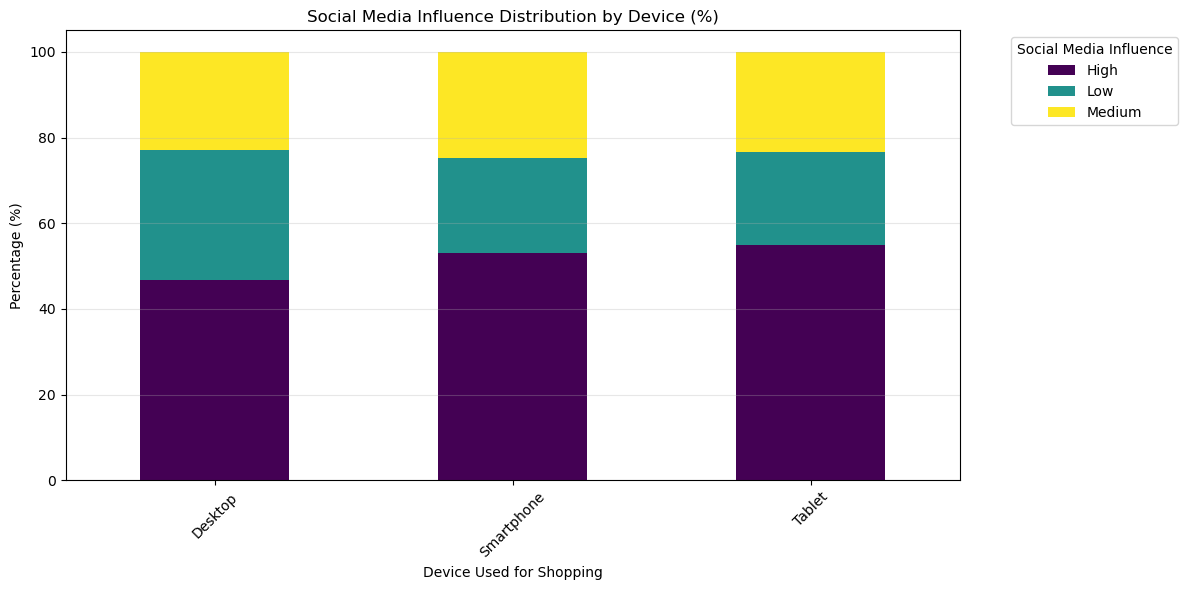

Social Media Influence by Device (%):
Social_Media_Influence   High    Low  Medium
Device_Used                                 
Desktop                 46.86  30.29   22.86
Smartphone              53.05  22.19   24.76
Tablet                  54.87  21.83   23.30


In [127]:
# PercentagCalculating the percentage of each influence level within each device
device_social_influence = (pd.crosstab(df['Device_Used'], df['Social_Media_Influence'], normalize='index') * 100).round(2)

# Creating stacked bar plot
device_social_influence.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Formatting the plot
plt.title('Social Media Influence Distribution by Device (%)')
plt.xlabel('Device Used for Shopping')
plt.ylabel('Percentage (%)')
plt.legend(title='Social Media Influence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "social_media_influence_by_device.png"))

plt.show()

# Printing table for exact values
print("Social Media Influence by Device (%):")
print(device_social_influence)

### 4.7.2 Advertisement Engagement Across Segments

Advertisement engagement will be recorded as an ordinal categorical variable with levels Low, Medium, and High. To enable meaningful comparison across customer segments, engagement was redefined as a binary indicator, where customers with Medium or High engagement were classified as engaged. 


 - Advertising Engagement by Age Group

In [128]:
# Encoding for ad engagement
df['Ad_Engaged'] = df['Engagement_with_Ads'].isin(['Medium', 'High']).astype(int)

# Age group performance and ad engagement rate
age_group_performance = (df.groupby('Age_Group', observed=False).agg(Avg_Purchase_Amount=('Purchase_Amount', 'mean'),
                                Ad_Engagement_Rate=('Ad_Engaged', 'mean')))

# Convert to percentage
age_group_performance['Ad_Engagement_Rate'] *= 100
age_group_performance.round(2)

,Avg_Purchase_Amount,Ad_Engagement_Rate
Age_Group,,
18-25,279.03,74.77
26-35,277.99,75.65
36-45,274.92,80.00
46-55,263.49,76.67


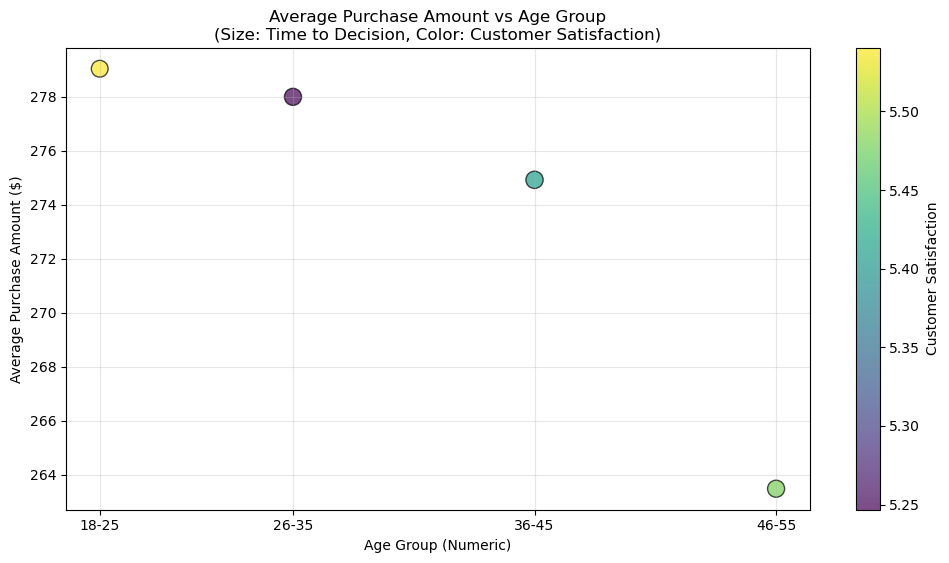

In [129]:
# Create age group data for visualization
df_avg_year = df.groupby('Age_Group', observed=False).agg({'Purchase_Amount': 'mean',
    'Customer_Satisfaction': 'mean', 'Time_to_Decision': 'mean'}).reset_index()

# Add numeric age for plotting
age_mapping = {'18-25': 22, '26-35': 30, '36-45': 40, '46-55': 50}
df_avg_year['Age_Numeric'] = df_avg_year['Age_Group'].map(age_mapping)

# Set up normalization for customer satisfaction (our third variable)
satisfaction_min = df_avg_year['Customer_Satisfaction'].min()
satisfaction_max = df_avg_year['Customer_Satisfaction'].max()
norm = plt.Normalize(vmin=satisfaction_min, vmax=satisfaction_max)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_avg_year['Age_Numeric'], df_avg_year['Purchase_Amount'], s=df_avg_year['Time_to_Decision'] * 20,  # Scale size for visibility
    c=df_avg_year['Customer_Satisfaction'],cmap='viridis', norm=norm, alpha=0.7, edgecolors='black')

plt.colorbar(scatter, label='Customer Satisfaction')
plt.title('Average Purchase Amount vs Age Group\n(Size: Time to Decision, Color: Customer Satisfaction)')
plt.xlabel('Age Group (Numeric)')
plt.ylabel('Average Purchase Amount ($)')
plt.xticks(list(age_mapping.values()), list(age_mapping.keys()))
plt.grid(alpha=0.3)

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "purchase_amount_vs_age_group.png"))

plt.show()

# Code adapted from https://medium.com/better-programming/visualizing-the-third-numeric-variable-in-python-eaf73f42219

### 4.8 Geographic Distribution & Market Performance

In [130]:
# Geographic Analysis Coverage
geo_df = df[df['Country'].notna()].copy()

# Calculate coverage
coverage = len(geo_df) / len(df)

print(f"Geographic analysis based on {coverage:.1%} of observations")

Geographic analysis based on 38.6% of observations


#### 4.8.1 Revenue Concentration by Country

In [131]:
# Grouping by Country and sum Purchase_Amount
country_revenue = df.groupby("Country")["Purchase_Amount"].sum().sort_values(ascending=False).head(10)
display(country_revenue)

Country
China            9267.96
Brazil           9222.87
United States    8709.67
France           6396.56
Russia           5987.47
Japan            5675.33
Philippines      3766.51
Indonesia        3302.30
Iran             3237.64
Sweden           2880.31
Name: Purchase_Amount, dtype: float64

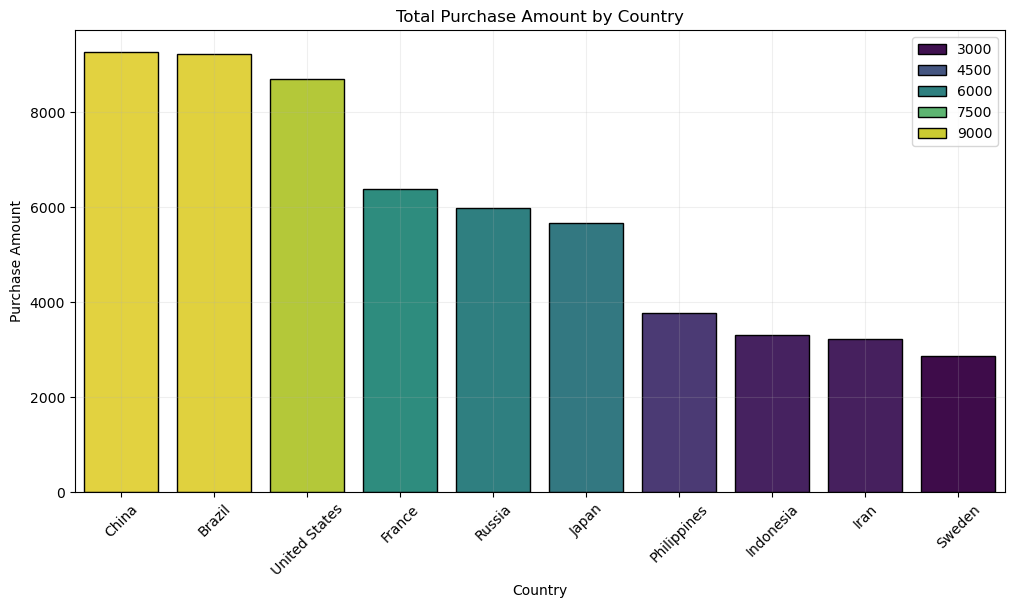

In [132]:
# Plotting the total purchase amount by country
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='viridis', edgecolor='black', hue=country_revenue.values)

# Formatting the plot
plt.title("Total Purchase Amount by Country")
plt.ylabel("Purchase Amount")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

# Saving the plot
PLOTS_DIR = "plots/"
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOTS_DIR, "purchase_amount_by_country.png"))

plt.show()

Revenue is concentrated in a small number of countries, indicating key markets for the organisation.

The regions may represent priority regions for targeted marketing, localisation strategies, and future investment.

#### 4.8.2 Brand Loyalty Across Key Markets

In [133]:
# Top 10 countries by total purchase amount
top_10_countries = country_revenue.head(10).index

# Average brand loyalty score by country (top 10 revenue countries)
top_10_loyalty = (df[df['Country'].isin(top_10_countries)].groupby('Country')['Brand_Loyalty']
                .mean().round(2).sort_values(ascending=False))
top_10_loyalty

Country
Indonesia        4.00
Iran             3.56
Brazil           3.38
Sweden           3.18
China            3.16
Philippines      3.00
France           2.84
Japan            2.81
United States    2.80
Russia           2.55
Name: Brand_Loyalty, dtype: float64

 - Average brand loyalty by country plot

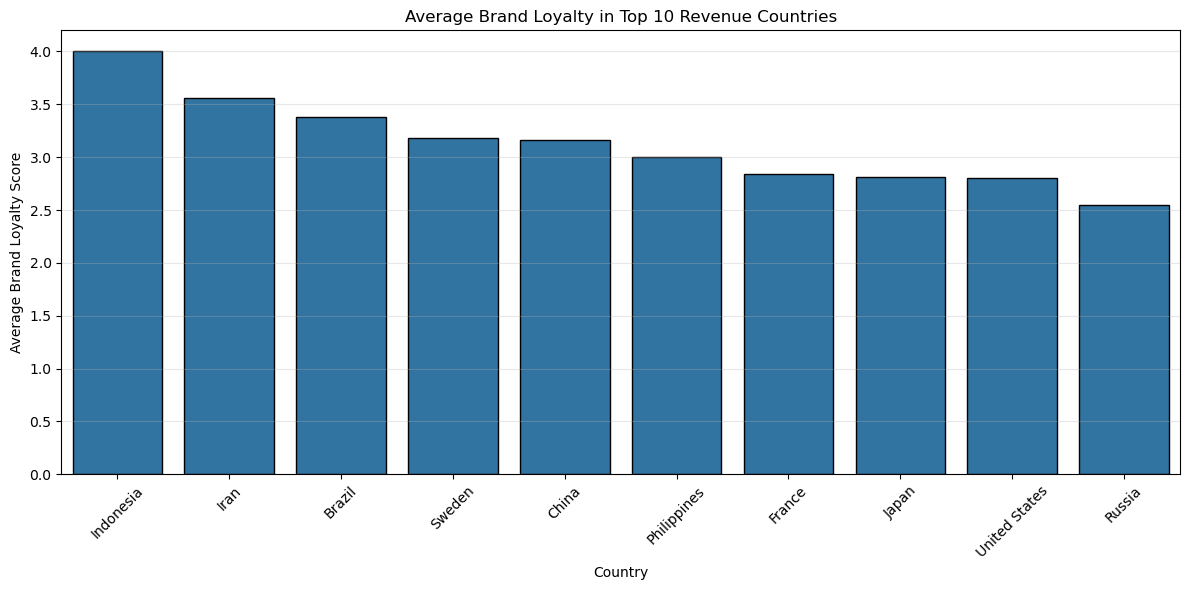

In [134]:
# Plotting average brand loyalty in top 10 revenue countries
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_loyalty.index, y=top_10_loyalty.values, edgecolor='black')

# Formatting the plot
plt.title("Average Brand Loyalty in Top 10 Revenue Countries")
plt.ylabel("Average Brand Loyalty Score")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "brand_loyalty_top_10_revenue_countries.png"))

plt.show()

The results indicate that brand loyalty varies across the organisation’s top revenue-generating countries. Some high-revenue markets also demonstrate strong customer loyalty, while others may rely more heavily on transactional purchases. These results can inform market-specific retention strategies.

### 4.9 Customer Satisfaction & Loyalty Indicators

This section evaluates overall customer satisfaction and explores how satisfaction varies across different customer segments and purchasing conditions. 

#### 4.9.1 Loyalty Programme Participation

In [135]:
# How many, in percentage terms, are members of our loyalty program?
loyalty_counts = df['Loyalty_Program_Member'].value_counts(normalize=True).round(4) * 100
loyalty_counts

Loyalty_Program_Member
False    50.9
True     49.1
Name: proportion, dtype: float64

#### 4.9.2 Overall Customer Satisfaction

In [136]:
# How many customers are highly satisfied (rating of 4 or more)?
highly_satisfied_counts = (df['Customer_Satisfaction'] >= 4).value_counts(normalize=True).round(3) * 100
highly_satisfied_counts

Customer_Satisfaction
True     68.5
False    31.5
Name: proportion, dtype: float64

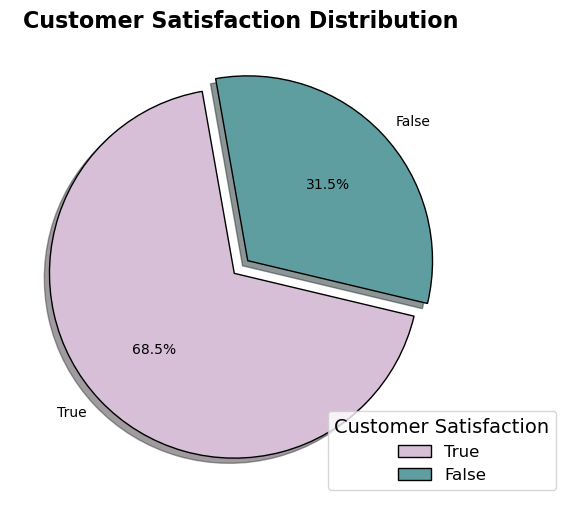

In [137]:
# And now for the big reveal, we'll plot the pie chart with nice colours and black edges to enhance visualisation
plt.figure(figsize=(12,6))
plt.pie(highly_satisfied_counts, labels=highly_satisfied_counts.index, autopct='%1.1f%%', colors=['thistle', 'cadetblue'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=100,
        explode=[0.05]*len(highly_satisfied_counts))

# Enhancing the plot
plt.gca().set_aspect('equal')  # Ensures that pie is drawn as a circle
plt.title("Customer Satisfaction Distribution", fontsize=16, fontweight='bold')
plt.legend(title="Customer Satisfaction", fontsize=12, title_fontsize=14, loc='lower right', bbox_to_anchor=(1.2, 0))

# Saving the plot
plt.savefig(os.path.join(PLOTS_DIR, "customer_satisfaction_distribution.png"))

plt.show()

# Source: https://matplotlib.org/stable/gallery/color/named_colors.html

The results indicate that a majority of customers report high satisfaction levels, suggesting that generally positive customer experiences, though further analysis is required to understand what factors contribute to satisfaction.

#### 4.9.3 Satisfaction by Age Group

In [138]:
# Customer satisfaction by age group
fig = px.box(df, x='Age_Group', y='Customer_Satisfaction', title='Customer Satisfaction by Age Group',
             color_discrete_sequence=px.colors.qualitative.Bold)

# Formatting the plot size
fig.update_layout(width=1200, height=600)

fig.show()

The boxplot suggests that customer satisfaction levels are fairly similar across Age Groups, with only minor differences in median ratings; indicating that overall satisfaction is relatively consistent across all groups.

### 4.10 Seasonal Purchasing Patterns

#### 4.10.1 Monthly Revenue Trends

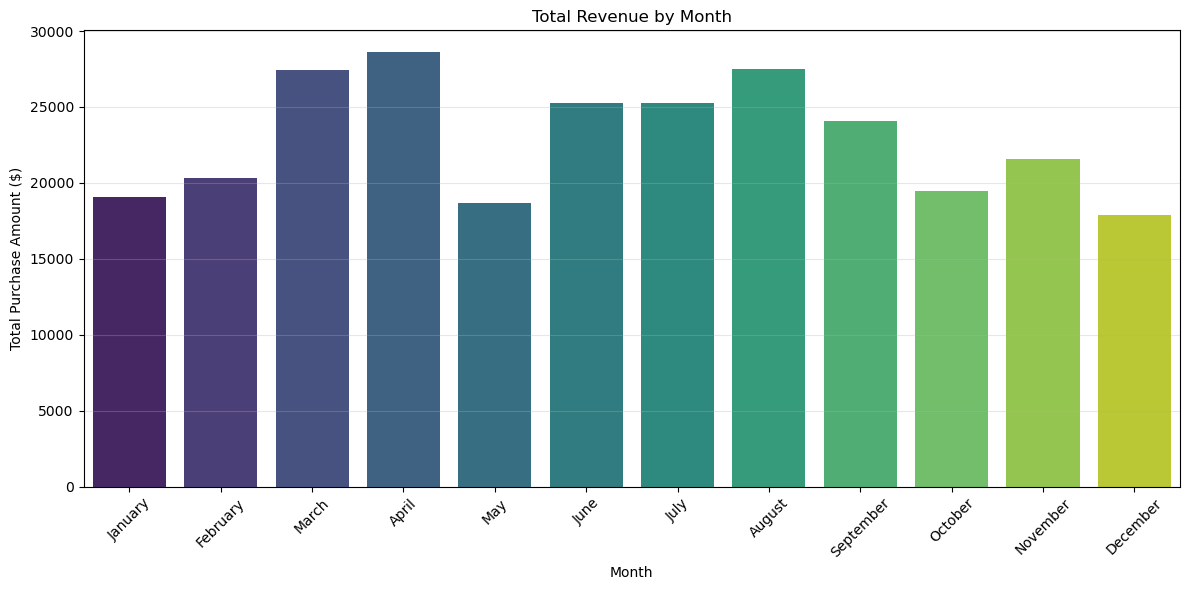

In [139]:
# Extract month information from Time_of_Purchase
df['Month'] = df['Time_of_Purchase'].dt.month
df['Month_Name'] = df['Time_of_Purchase'].dt.month_name()

# Aggregate total revenue by month
monthly_revenue = df.groupby(['Month', 'Month_Name'])['Purchase_Amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Month')  # Ensure chronological order

# Plot Total Revenue by month
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_revenue, x='Month_Name', y='Purchase_Amount', hue='Month_Name', palette='viridis')

# Formatting the plot
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Saving the plot
PLOTS_DIR = "plots/"
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOTS_DIR, "total_revenue_by_month.png"))

plt.show()

The exploratory analysis revealed meaningful variation in purchasing behaviour across demographic segments, product categories, channels, and geographic markets. While many relationships were modest in strength, consistent patterns emerged around purchase intent, device usage, loyalty indicators, and seasonal effects. These insights not only support strategic interpretation but also motivate the use of structured querying and predictive modelling, which are explored in the following sections.

## 5. Database Integration (SQL Analysis)

In production analytics environments, customer data is typically stored and queried within relational databases rather than analysed exclusively in-memory. Demonstrating the ability to reproduce analytical insights using [SQL](https://www.alooba.com/skills/tools/programming-fundamentals-141/sql-integration/#:~:text=SQL%20integration%20helps%20organizations%20consolidate,and%20facilitating%20more%20comprehensive%20analysis.) is therefore an important practical skill.


🔹 Step 1: Create SQLite database

In [99]:
# Create SQLite database and add it to data directory
conn = sqlite3.connect("data/consumer_behaviour.db")

# Write dataframe to SQL table
df.to_sql("customers", conn, if_exists="replace", index=False)

print("Database created and table populated.")

Database created and table populated.


🔹 Step 2: Example SQL Queries (This Is Where Marks Come From)

In [100]:
# Query 1: Average purchase amount by age group

query_1 = '''
SELECT Age_Group,
       ROUND(AVG(Purchase_Amount), 2) AS Avg_Purchase
FROM customers
GROUP BY Age_Group
ORDER BY Avg_Purchase DESC;
'''

pd.read_sql(query_1, conn)

,Age_Group,Avg_Purchase
0,18-25,279.03
1,26-35,277.99
2,36-45,274.92
3,46-55,263.49


In [101]:
# Query 2: Revenue by country (Top 5)

query_2 = '''
SELECT Country,
       ROUND(SUM(Purchase_Amount), 2) AS Total_Revenue
FROM customers
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 5;
'''

pd.read_sql(query_2, conn)

,Country,Total_Revenue
0,None,170689.11
1,China,9267.96
2,Brazil,9222.87
3,United States,8709.67
4,France,6396.56


In [102]:
# Query 3: Loyalty vs Spending

query_3 = '''
SELECT Loyalty_Program_Member,
       ROUND(AVG(Purchase_Amount), 2) AS Avg_Purchase
FROM customers
GROUP BY Loyalty_Program_Member;
'''

pd.read_sql(query_3, conn)

,Loyalty_Program_Member,Avg_Purchase
0,0,288.37
1,1,261.27


In [103]:
# Query 4: Device × Social Media Influence

query_4 = """
SELECT Device_Used,
       Social_Media_Influence,
       COUNT(*) AS Count
FROM customers
GROUP BY Device_Used, Social_Media_Influence
ORDER BY Device_Used;
"""

pd.read_sql(query_4, conn)


,Device_Used,Social_Media_Influence,Count
0,Desktop,High,164
1,Desktop,Low,106
2,Desktop,Medium,80
3,Smartphone,High,165
4,Smartphone,Low,69
5,Smartphone,Medium,77
6,Tablet,High,186
7,Tablet,Low,74
8,Tablet,Medium,79


🔹 Step 3: Close the connection

In [104]:
conn.close()

This section demonstrated how the cleaned dataset can be stored in a relational database and queried using SQL to replicate key analytical findings. The results align closely with insights obtained using pandas, illustrating how Python and SQL can be combined to support scalable and efficient customer analytics workflows. Building on these descriptive insights, the next section applies machine learning techniques to quantify the influence of customer characteristics on purchase behaviour.

## 6. Modelling & Machine Learning

In this section, machine learning techniques are applied to model customer behaviour and explore the predictive power of selected features. The goal is not only to build a production-level system, but also to demonstrate how data-driven models can support decision-making in a consumer analytics context.

### 6.1 Objective of Modelling

Exploratory data analysis highlighted consistent differences in purchasing behaviour across customer segments, including variations by age group, purchase intent, device type, and loyalty indicators.

The objective of this modelling phase is therefore not to produce highly accurate transaction-level forecasts, but to explore whether customer demographics, behavioural signals, and purchase context can be used to explain and approximate differences in purchase amount. This reflects common use cases in customer analytics, where models are primarily employed for segmentation, targeting, and strategic decision support rather than precise forecasting.

Given that purchase amount is a continuous variable with high natural variability, regression-based approaches are appropriate.

### 6.2 Feature Selection & Data Preparation

Feature selection was informed by findings from the exploratory analysis and guided by business relevance. The selected variables capture a combination of demographic characteristics (age, gender), behavioural indicators (brand loyalty, purchase intent, discount usage), and contextual factors related to the purchasing process (device used, payment method, time to decision).

Categorical variables were encoded using one-hot encoding to enable their inclusion in regression models, while numerical features were retained in their original scale. The dataset was split into training and test sets using an 80/20 split to allow out-of-sample evaluation of model performance.

This approach prioritises interpretability and alignment with the analytical objectives of the project.

🔹 Step 1: Select features & target

In [105]:
# Select features and target variable
features = ['Age', 'Brand_Loyalty', 'Time_to_Decision', 'Discount_Used', 'Purchase_Intent',
    'Device_Used','Payment_Method', 'Gender']

X = df[features]
y = df['Purchase_Amount']

🔹 Step 2: Encode categorical variables

In [106]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

🔹 Step 3: Train-test split

In [107]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

🔹 Step 4: Linear Regression model

A multiple linear regression model was implemented as a baseline approach due to its simplicity, transparency, and suitability for explanatory analysis. Linear regression allows direct interpretation of coefficients, making it well suited to understanding the directional impact of individual features on purchase amount.

Model performance was evaluated using Mean Absolute Error (MAE) and the coefficient of determination (R²). To contextualise model performance, a naïve baseline was established by predicting the mean purchase amount for all observations in the test set. This baseline represents the simplest possible predictor and provides a reference point for assessing whether the model adds value beyond a constant average. The baseline Mean Absolute Error (MAE) was higher than that of the linear regression model, indicating that incorporating customer demographics, behavioural indicators, and contextual features improves predictive performance relative to an average-based approach. While the reduction in error is modest, it demonstrates that the model extracts meaningful signal beyond the baseline.

The model achieved a Mean Absolute Error of approximately $117, indicating that predicted purchase values differ from actual transaction amounts by this amount on average. Given the wide range of purchase values observed during exploratory analysis, this level of error is considered reasonable for behavioural transaction data. The R² score was negative, indicating that the model does not explain a substantial proportion of the total variance in purchase amount.

Rather than indicating a modelling failure, this result reflects the inherently noisy nature of consumer spending behaviour, which is influenced by many unobserved factors such as product pricing, urgency, and external context.

In [108]:
# Baseline model: Predict the mean purchase amount
baseline_pred = np.full_like(y_test, y_test.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline MAE (mean predictor): {baseline_mae:.2f}")

Baseline MAE (mean predictor): 115.43


In [109]:
# Initialise and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

🔹 Step 5: Model evaluation

In [110]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: 115.24
R² Score: -0.014


While the model is not intended for precise forecasting, it demonstrates how customer intent, loyalty, and contextual factors can be leveraged to support data-driven decision-making.

**Feature Importance**

In [111]:
# Feature coefficients from the linear regression model
coefficients = pd.Series(model.coef_, index=X_encoded.columns)
coefficients.sort_values(key=abs, ascending=False)

Purchase_Intent_Wants-based    35.602778
Purchase_Intent_Need-based     29.119170
Device_Used_Smartphone         21.511866
Device_Used_Tablet             16.159637
Gender_Other                  -15.896963
Gender_Male                   -12.682832
Purchase_Intent_Planned        12.427945
Payment_Method_Other           11.591247
Discount_Used                 -10.351490
Payment_Method_Paypal           9.864260
Brand_Loyalty                  -9.239496
Payment_Method_Credit Card     -8.363766
Payment_Method_Debit Card      -7.262995
Age                            -0.221343
Time_to_Decision               -0.018375
dtype: float64

### 6.3 Interpretation of Results

Although predictive accuracy is limited, the linear regression model provides meaningful directional insight into the drivers of purchase value. Analysis of model coefficients highlights the relative importance of behavioural variables such as purchase intent, brand loyalty, and device type, which consistently align with patterns observed during exploratory data analysis.

Features associated with stronger intent and higher loyalty tend to increase predicted purchase amount, while longer decision times and certain device or payment categories are associated with lower predicted values. These relationships are consistent with established consumer behaviour theory, where engagement and purchase motivation are key drivers of transaction value.

From a practical perspective, these results demonstrate how even simple and interpretable models can support strategic decision-making by identifying variables that are associated with higher-value purchases.

### 6.4 Alternative Model: Random Forest Regression

To assess whether non-linear relationships improve model performance, a Random Forest regression model was implemented and compared against the linear regression baseline. Random Forests are capable of capturing complex interactions between variables without requiring explicit feature transformations.

The Random Forest model produced performance metrics similar to those of the linear regression model, with only marginal differences in error and explanatory power. Feature importance analysis again identified behavioural variables—particularly purchase intent, brand loyalty, and time to decision—as the most influential predictors of purchase amount.

The limited improvement in performance suggests that while non-linear interactions are present, they do not substantially overcome the inherent variability of transaction-level purchase behaviour in this dataset.

**Step 1: Train the model**

In [112]:
# Initialise and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

**Step 2: Evaluate performance**

In [113]:
# Predicting with Random Forest model
rf_preds = rf_model.predict(X_test)

# Evaluating Random Forest model
rf_mae = mean_absolute_error(y_test, rf_preds)

# Calculating R² score
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest R²: {rf_r2:.3f}")

Random Forest MAE: 116.99
Random Forest R²: -0.082


**Feature Importance Plot**

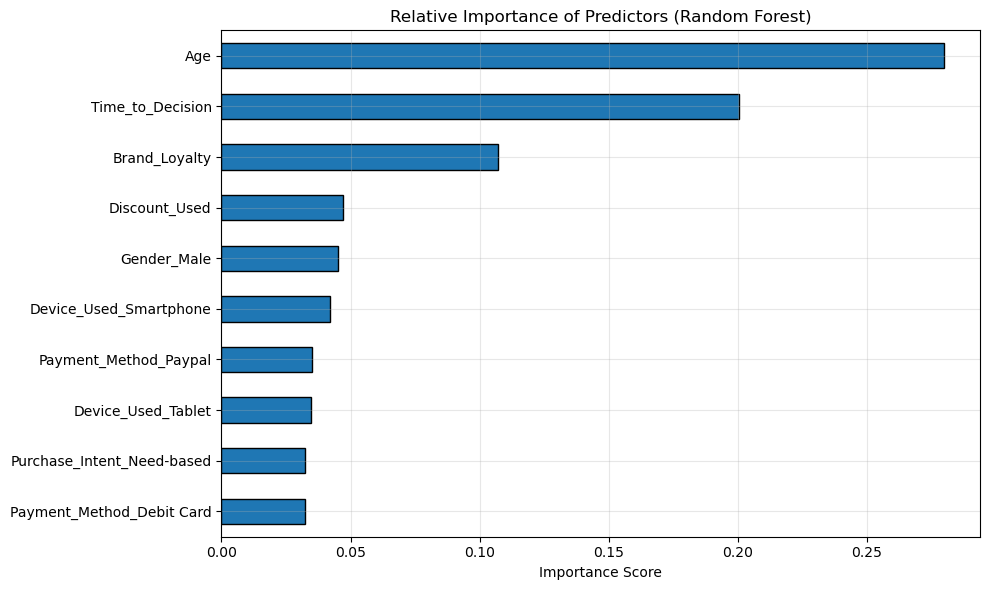

In [114]:
# Feature importance from Random Forest model
importances = pd.Series(rf_model.feature_importances_,index=X_encoded.columns).sort_values(key=abs, ascending=False)

# Plotting the top 10 feature importances
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh', edgecolor='black')

# Formatting the plot
plt.title("Relative Importance of Predictors (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Model Evaluation & Limitations

Overall, both modelling approaches demonstrate **limited predictive accuracy but consistent value**. This outcome is expected for transaction-level consumer spending data, which is characterised by high variance and strong influence from factors not taken into account.

The models are best interpreted as **tools for understanding relative influences and supporting segmentation and targeting strategies**, rather than as precise forecasting systems. Also, the consistency between EDA, linear regression coefficients, and Random Forest feature importance strengthens confidence in the identified drivers of purchase value.

These findings reinforce the role of behavioural and contextual data in customer analytics and provide support for strategic insights presented in the following section.

## 7. Conclusions & Strategic Insights

Synthesising results across descriptive analysis, database querying, and predictive modelling enables the translation of technical findings into actionable business insights. This section integrates evidence from across the project to inform strategic recommendations.

### 7.1 Customer Demographics & Profiling

The customer base is predominantly young to middle-aged, with an average age of 34.3 years and the majority falling within the 18–45 age range. No customers aged 55+ are present in the dataset, suggesting the platform primarily attracts younger consumers. Female customers represent 45.2% of the customer base and demonstrate the highest average spending per purchase ($282.09), followed closely by customers identifying as Other and Male customers.

Clear differences in category preferences emerge across age groups. Customers aged 18–25 show strong interest in Sports & Outdoors, Mobile Accessories, and Office Supplies, while those aged 26–35 favour Groceries, Animal Feed, and Food & Beverages. Customers aged 36–45 are more inclined toward Electronics, Jewellery & Accessories, and Packages, whereas the 46–55 group displays greater interest in Toys & Games and Beauty & Personal Care. Average spending is highest among the youngest age group and gradually declines with age.

Category preferences also vary by gender. Female customers dominate Jewellery & Accessories, Electronics, and Health Care, while Male customers show stronger preferences for Home Appliances, Gardening & Outdoors, and Software & Apps. Customers identifying as Other exhibit particularly strong engagement with Packages and Home Appliances. These differences support the feasibility of demographic-based product segmentation.


[Market Segmentation & Consumer Profiles](https://www.kotlermarketinggroup.com/market-segmentation/)

[Nielsen – Understanding Consumer Demographics](https://nielseniq.com/global/en/info/consumer-data/)

[Customer vs Market Segmentation: Key Differences for Better ROI](https://brandspeak.co.uk/blog/what-is-the-difference-between-customer-segmentation-and-market-segmentation/)

### 7.2 Purchasing Habits & Drivers

The average purchase amount across customers ranges between approximately $274 and $282. All customers in the dataset are repeat buyers (purchase frequency >1), indicating either exceptionally strong retention or a dataset that focuses exclusively on repeat purchasers. Nearly half of customers (49.1%) are members of the loyalty programme, and 68.5% report high satisfaction levels (rating ≥4), suggesting generally positive customer experiences.

Purchase intent analysis reveals wide spending distributions across all intent types. Need-based and impulsive purchases exhibit the greatest variability and the highest outliers, indicating that both functional necessity and spontaneous decisions can lead to high-value transactions.

Discount usage is common across all genders (approximately 50–56%), with the highest usage observed among customers identifying as Other. However, no strong relationship between discount usage and customer satisfaction or spending was identified, suggesting that discounts alone may not significantly influence perceived value or long-term satisfaction.

[The Psychology Behind Customer Spending](https://npfulfilment.com/the-psychology-behind-customer-spending-why-consumers-buy/])

[Consumer Buying Behaviour](https://www.youngurbanproject.com/consumer-buying-behaviour/)

[Factors That Influence Consumer Purchasing Decisions](https://pimberly.com/blog/factors-influence-consumer-purchasing-decisions/)


### 7.3 Channels & Payment Preferences

Device usage analysis highlights the importance of mobile platforms. Smartphone and tablet users display the highest levels of social media influence, particularly among younger age groups (18–35), reinforcing the importance of mobile-first design and social media–driven marketing strategies.

Payment behaviour shows clear preferences, with PayPal accounting for the highest number of transactions and total revenue. Credit cards generate the highest average revenue per transaction, while cash payments are associated with lower average purchase amounts. These findings suggest that encouraging digital payment methods may support higher-value transactions and smoother checkout experiences.

[Consumer journeys have changed.](https://business.google.com/us/think/consumer-insights/new-consumer-decision-making-process/)

[The consumer behaviors shaping the next generation of mobile experiences](https://www.thinkwithgoogle.com/consumer-insights/consumer-trends/consumer-behavior-mobile-digital-experiences/)

[The future of digital payments](https://y.uno/post/future-digital-payments)

[Digital Payment Technologies: The Future of Money and Transactions](https://neontri.com/blog/digital-payment-technologies/)

### 7.4 Geographic & Loyalty Insights

Revenue is concentrated within a small number of countries, with the top ten markets accounting for a substantial proportion of total purchase value. When controlling for market size by using average brand loyalty scores, notable differences in customer loyalty emerge across these key markets. Some high-revenue countries also demonstrate strong average loyalty, while others appear more transaction-driven, highlighting opportunities for targeted retention strategies in specific regions.

Overall loyalty indicators are strong, with high repeat purchase rates and substantial loyalty programme participation. However, customers with lower purchase frequency, lower satisfaction scores, or lower loyalty scores may warrant closer monitoring as potential churn-risk segments.

[Loyalty Trends: What’s Next & Why It Matters](https://mando.co.uk/loyalty-trends-whats-next-why-it-matters/)
[Loyalty Programs Are Growing—So Are Customer Expectations](https://www.bcg.com/publications/2024/loyalty-programs-customer-expectations-growing)

### 7.5 Seasonal Patterns

The purchasing activity by month reveals clear seasonal patterns. Both transaction volume and total revenue peak during spring and summer months, particularly in April and August, while December records the lowest activity levels. This suggests that promotional efforts and inventory planning may be most effective when aligned with periods of naturally higher demand.

[The Impact of Seasonal Trends on Your Marketing Campaigns](https://pmamilwaukee.com/blog/the-impact-of-seasonal-trends-on-your-marketing-campaigns)

### 7.6 Marketing Strategy

Based on the analysis, the primary target segment consists of customers aged 18–35, particularly females using smartphones or tablets who are highly influenced by social media and frequently purchase categories such as Jewellery & Accessories, Electronics, and Groceries. This segment is well suited to mobile-optimised campaigns, personalised recommendations, and social media advertising.

Marketing effectiveness appears strongest on mobile devices and among younger demographics, supporting continued investment in mobile and social channels. From a geographic perspective, prioritising top-revenue countries for loyalty-building initiatives could strengthen long-term customer value. Encouraging the use of digital payment methods and timing promotional campaigns around peak seasonal periods may further enhance performance.

Although transaction-level prediction remains challenging, comparison against a simple baseline confirms that customer-level features provide measurable explanatory value beyond simple average-based assumptions.

[Marketing Strategy: definition, importance and guide](https://ie.indeed.com/career-advice/career-development/marketing-strategy)

[The State of Data-Driven Marketing](https://blog.hubspot.com/agency/data-driven-marketing)

[How to create an effective sales and marketing strategy](https://www.thinkbusiness.ie/articles/how-to-create-an-effective-sales-and-marketing-strategy/)

The analysis highlights clear opportunities for demographic targeting, mobile-first engagement strategies, loyalty programme optimisation, and seasonally aligned marketing initiatives. While individual transaction values are difficult to predict precisely, consistent behavioural patterns emerge that can support segmentation, personalisation, and long-term customer value strategies. The final section outlines the limitations of the analysis and contextualises the findings.

## 8. Research Limitations

As with any data-driven study, the insights derived from this analysis must be interpreted in light of the dataset’s scope, assumptions, and methodological constraints.

* **Geographic Coverage Limitations**
Country-level analysis was derived using an offline city-to-country mapping approach (geonamescache). This method relies on exact city name matches and does not support location variants. As a result, only a subset of observations could be reliably mapped to countries. Geographic insights are therefore based on this validated subset and may not be representative of the full dataset.

* **Location Granularity Reduction**
Original location data was provided at city level but was aggregated to country level to simplify analysis and improve interpretability. This aggregation may mask regional or city-specific differences in consumer behaviour within countries.

* **Data Processing & Analysis Choices** 
Some analytical decisions were made for simplicity that affect how results should be interpreted:

    * **Rating Scale Treatment:** Customer satisfaction (1-5 scale) and brand loyalty scores were analysed as regular numbers rather than as ordered categories. This means calculations like averages might not fully capture how customers actually use these ratings.

    * **Outlier Handling:** High purchase amounts were kept in the data without adjustment. While these might be VIP customers, they can skew averages and statistical relationships.

* **Dataset Scope & Representativeness**
The dataset represents a snapshot of consumer behaviour within a specific e-commerce context and may not generalise to other industries, platforms, or geographic markets. Observed patterns should therefore be interpreted within the scope of the dataset.

* **Lack of Temporal Depth**
While monthly purchasing patterns were analysed, the dataset does not span multiple years. This limits the ability to identify long-term trends or distinguish seasonal effects from short-term fluctuations.

* **Limited Behavioural Variables**
Certain factors that may influence purchasing behaviour — such as competitor pricing, or external economic conditions. These are not available in the dataset. Their absence may limit the  results of the exploratory analysis and the predictive models.

* **Model Simplicity & Predictive Power**
The machine learning models achieved limited predictive accuracy (R² < 0.3), indicating that purchase amount is influenced by factors beyond the available dataset. While the models identify important relationships, they should not be used for precise individual predictions without additional feature engineering and external data sources.

* **Potential Self-Selection Bias**
All customers in the dataset appear to be repeat purchasers, which may introduce bias toward more engaged or loyal customers. This limits insights into first-time buyers or churn behaviour.

Acknowledging these constraints ensures that conclusions are interpreted appropriately and highlights opportunities for future research, such as incorporating richer behavioural data, longitudinal observations, and more advanced predictive techniques.

 END